In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import glob, os, shutil, cv2, json, sys
from tqdm import tqdm
from pathlib import Path

In [2]:
BASE_PATH = f'../Dataset/{Path().resolve().name}'
BASE_PATH

'../Dataset/facies'

In [3]:
def getFiles(path, limit=None, shuffle=False):
    target = sorted([os.path.abspath(f) for f in glob.glob(os.path.join(path, '*'))])
    if shuffle:
        np.random.shuffle(target)
    return target[:limit]

def setFolder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)


OPTIONS = json.loads(open('../../Task/info.json', 'r').read())
OPTIONS['dataset'] = BASE_PATH.split('/')[-1].strip()
OPTIONS

{'network': 'resaceunet',
 'multi-gpu': True,
 'dataset': 'facies',
 'img_size': [4, 256, 256],
 'step': 3,
 'multiclass': True,
 'lr': 0.0005,
 'loss': 'dice_focal',
 'batch_size': 16,
 'scheduler': 'plateau',
 'dropout': 0.05,
 'num_filters': 32}

In [4]:
with open('../../Task/info.json', 'w', encoding='utf-8') as file:
    json.dump(OPTIONS, file, ensure_ascii=False, indent=4)

# CARREGANDO O VOLUME

In [5]:
RAW_DIR      = 'files/'
SEISMIC_PATH = os.path.join(RAW_DIR, 'marlim_norm_perc_1-99_cut.npy')
MASK_PATH    = os.path.join(RAW_DIR, 'npy_multiclass_cut.npy')

IMG_SIZE = tuple(OPTIONS['img_size'])
STEP     = OPTIONS.get('step', 3)

seismic = np.load(SEISMIC_PATH, mmap_mode='r')
masks   = np.load(MASK_PATH,    mmap_mode='r')

n_classes = int(np.max(masks[::200])) + 1
print(seismic.shape, seismic.dtype, '| classes:', n_classes)

(3137, 552, 2050) float32 | classes: 6


In [6]:
def showTile(img=None, mask=None, save=None):
    ref = img if img is not None else mask
    mx, my, mz = ref.shape[0] // 2, ref.shape[1] // 2, ref.shape[2] // 2

    def get_slices(vol):
        if vol is None:
            return None
        return [np.array(vol[mx, :, :]), np.rot90(np.array(vol[:, :, mz]), -1), np.array(vol[:, my, :])]

    img_slices, mask_slices = get_slices(img), get_slices(mask)

    if mask is not None:
        n = int(np.nanmax(mask)) + 1
        colors = ['black', '#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4'][:max(n, 2)]
        cmap_solid   = ListedColormap(colors)
        over = list(colors); over[0] = (0, 0, 0, 0)
        cmap_overlay = ListedColormap(over)
        vmax = max(n, 2) - 1

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    titles = [f'Slice X={mx}', f'Slice Y={my}', f'Slice Z={mz}']
    for i, ax in enumerate(axes):
        if img is not None:
            ax.imshow(img_slices[i], cmap='gray')
        if mask is not None:
            if img is not None:
                ax.imshow(mask_slices[i], cmap=cmap_overlay, vmin=0, vmax=vmax, alpha=0.6)
            else:
                ax.imshow(mask_slices[i], cmap=cmap_solid, vmin=0, vmax=vmax)
        ax.set_title(titles[i])
    plt.tight_layout()
    if save:
        plt.savefig(save, bbox_inches='tight', dpi=300); return plt.close(fig)
    plt.show()

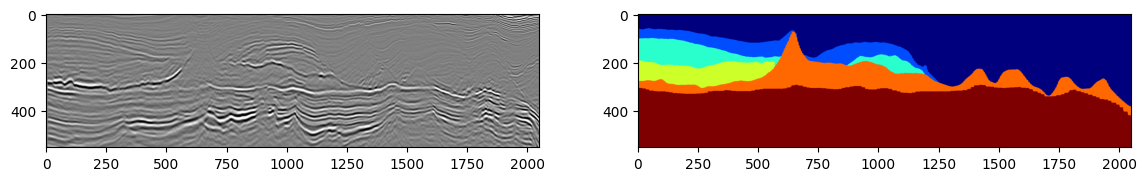

In [7]:
i = seismic.shape[0] // 2
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(np.asarray(seismic[i]), cmap='gray', vmin=0, vmax=1)
ax[1].imshow(np.asarray(masks[i]), cmap='jet', vmin=0, vmax=n_classes - 1)
plt.show()

# TILES

In [8]:
class TilesBuilder:
    def __init__(self, target_size, step, main_dir='tiles'):
        self.tz, self.ty, self.tx = target_size
        self.step = step
        setFolder(os.path.join(main_dir, 'images'))
        setFolder(os.path.join(main_dir, 'masks'))
        self.img_dir  = os.path.join(main_dir, 'images')
        self.mask_dir = os.path.join(main_dir, 'masks')

    def pad(self, vol, is_mask=False):
        pads = [(0, (s - vol.shape[i] % s) % s) for i, s in enumerate((self.tz, self.ty, self.tx))]
        if all(p == 0 for _, p in pads):
            return vol
        return np.pad(vol, pads, mode='edge' if is_mask else 'reflect')

    def build(self, seismic, masks):
        rows, k = [], 0
        for z in tqdm(range(0, seismic.shape[0], self.tz*self.step)):
            img = self.pad(np.asarray(seismic[z:z + self.tz], dtype=np.float32))
            msk = self.pad(np.asarray(masks[z:z + self.tz]).astype(np.uint8), is_mask=True)

            for y in range(0, img.shape[1], self.ty):
                for x in range(0, img.shape[2], self.tx):
                    it = img[:, y:y + self.ty, x:x + self.tx]
                    mt = msk[:, y:y + self.ty, x:x + self.tx]

                    name = f'img_{k:05d}.npy'
                    ip = os.path.abspath(os.path.join(self.img_dir,  name))
                    mp = os.path.abspath(os.path.join(self.mask_dir, name))
                    
                    data = {
                        'img_path': ip, 'mask_path': mp, 'shape': it.shape,
                        'min': float(it.min()), 'max': float(it.max()),
                        'mean': float(it.mean()), 'std': float(it.std()),
                        'msk_max': int(mt.max())
                    }

                    np.save(ip, it)
                    np.save(mp, mt)
                    rows.append(data)
                    k += 1
        return rows


tiles = TilesBuilder(IMG_SIZE, STEP)
rows  = tiles.build(seismic, masks)
print(len(rows), 'tiles')

100%|██████████| 262/262 [02:00<00:00,  2.17it/s]

7074 tiles


In [9]:
df = pd.DataFrame(rows)
df.to_csv('../DataBase.csv', index=None)
df

,img_path,mask_path,shape,min,max,mean,std,msk_max
0,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.229268,0.778868,0.502732,0.037087,3
1,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,0.937083,0.502533,0.038899,4
2,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.502285,0.046293,4
3,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.357488,0.732417,0.502492,0.019550,4
4,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.501868,0.083783,4
...,...,...,...,...,...,...,...,...
7069,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.497164,0.248731,5
7070,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.491530,0.283405,5
7071,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.500084,0.218975,5
7072,/home/grva-mintcave/Projects/Facies/Dataset/fa...,/home/grva-mintcave/Projects/Facies/Dataset/fa...,"(4, 256, 256)",0.000000,1.000000,0.499803,0.119612,5


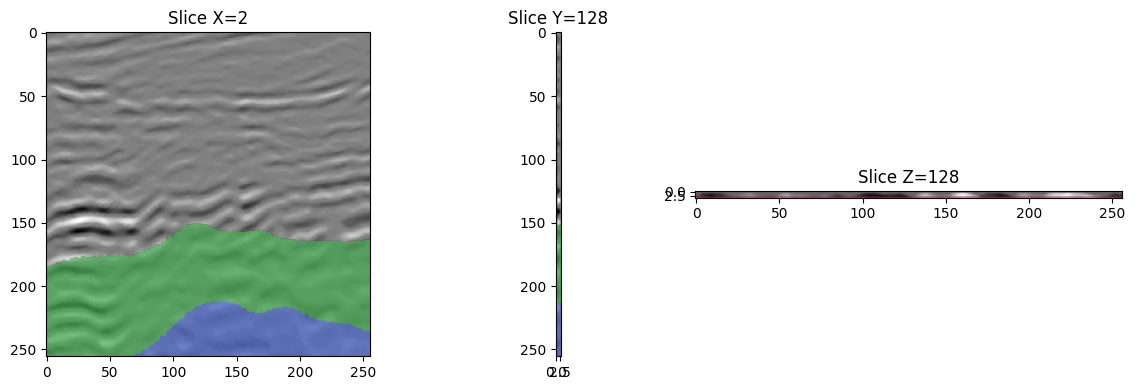

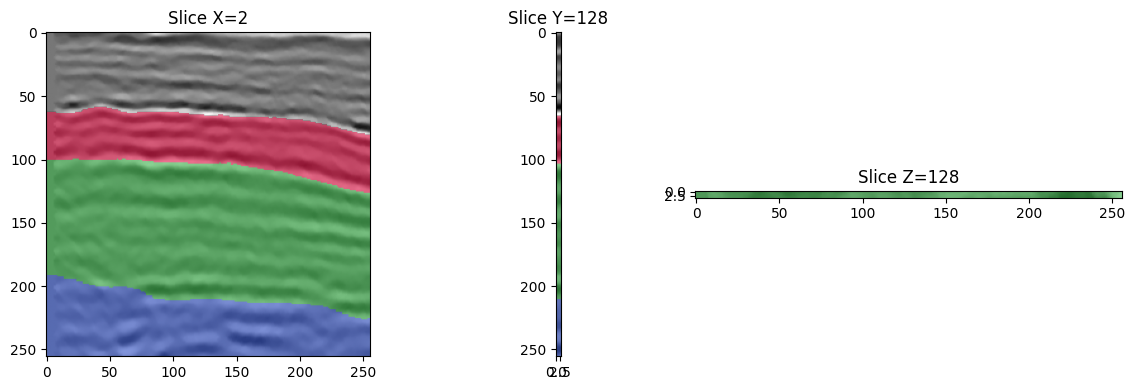

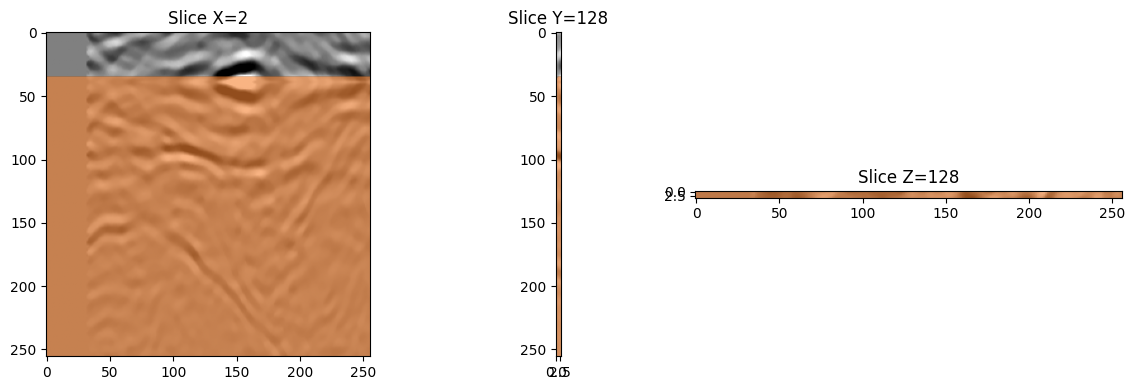

In [10]:
for index in [0, len(df) // 2, len(df) - 1]:
    row = df.iloc[index]
    showTile(img=np.load(row.img_path), mask=np.load(row.mask_path))